Loading CSV...
Unigram chart saved: unigram_chart.png
Unigram CSV saved: unigrams.csv


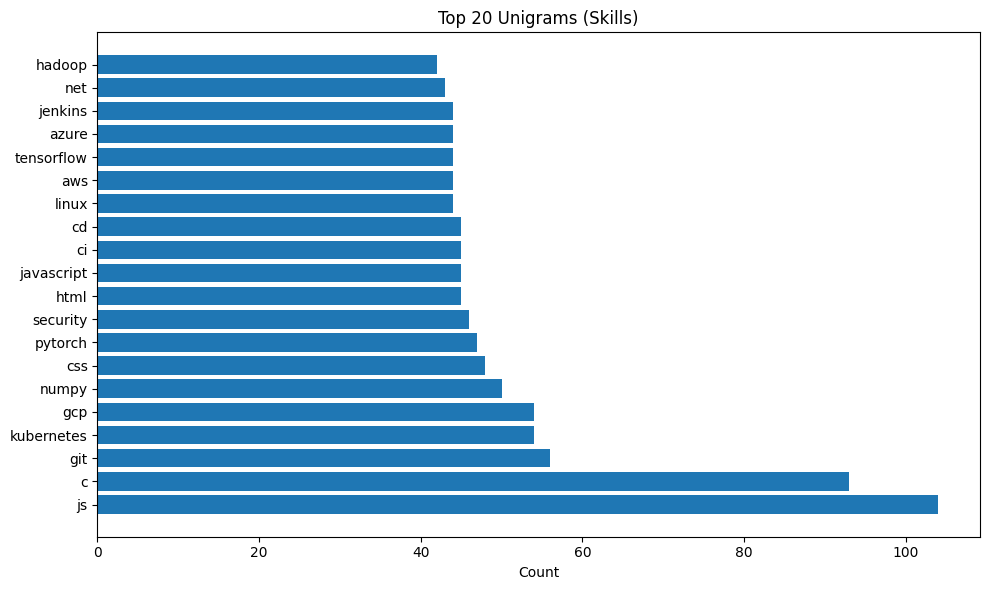

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter


def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9 ]", " ", text)
    return text

# CSV load
print("Loading CSV...")
df = pd.read_csv(r"jobs.csv")

# skills Column
skills_corpus = ""
for s in df['Skills'].dropna():
    skills_corpus += " " + clean_text(s)

# seperate word
words = skills_corpus.split()

# unigram content
unigram_counts = Counter(words)

top_unigrams = unigram_counts.most_common(20)

# drowing chirt
labels = [u[0] for u in top_unigrams]
values = [u[1] for u in top_unigrams]

plt.figure(figsize=(10,6))
plt.barh(labels, values)
plt.title("Top 20 Unigrams (Skills)")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig("unigram_chart.png")
print("Unigram chart saved: unigram_chart.png")


pd.DataFrame(top_unigrams, columns=['Unigram','Count']).to_csv("unigrams.csv", index=False)
print("Unigram CSV saved: unigrams.csv")
